A classical problem in operations management is inventory management. Here we manage to apply DRL method to the following inventory management problems: \\

Lost Sales Inventory Replenishment:  Consider the periodic-review inventory replenishment of a single item over an innite horizon. In
 the conventional lost sales model, inventory can be replenished at unit cost $c$ with lead time $l$. At
 the beginning of any period $t$, the order quantity, $q_t \geq 0$, must be decided knowing the last observed
 inventory on hand $I_{t-1}$. If $l = 0$, then the order is delivered immediately, otherwise the order at times $t-l$ arrived as $q_{t-l}$. A demand from the customer $d_t$ is then realized, and if the inventory is not enough excess demand will be lost. As a consequence, the next period on hand inventory evolves as $I_t = [I_{t-1} + q_{t-l} - d_t]^+$. \\
 To describe the system state, we use an $l+1$ dimension state vector $S_t = (I_{t-1}, Q_{t-1})$, where $Q_{t-1} = (q_{t-l}, q_{t-l+1}, \dots, q_{t-1})$. The action vector for the lost sales problem is one-dimensional consisting of the
 units ordered $a_t = (q_t)$. Cost at time $t$ is a combination of replenishment cost $cq_t$, holding cost $hI_t$ and lost sale cost $p[d_t - I_{t-1} - q_{t-1}]^+$:
 \begin{equation*}
c(S_t,a_t) = cq_t + hI_t + p[d_t - I_{t-1} - q_{t-1}]^+
 \end{equation*}
The value function starting from state $S_t$ with policy $\pi$ is defined as:
\begin{equation*}
V^{\pi}(S_t) = \sum\limits_{j=0}^{\infty} \gamma^j \mathrm{E}^{\pi}[c(S_{t+j}, a_{t+j})]
 \end{equation*}
 We assume $d_t$ follows Poisson distribution with rate $\lambda = 5$, and the ordering cost $c = 0$, the unit holding cost $h = 1$. Lead time varies from $l = 2,3,4$ and the lost sale cost $p = 4,9$. The discounting factor is set as $\gamma = 0.99$. \\

 Here the goal is to find a policy $\pi^{\ast}$ that minimize the discounting cost, due to the curse of dimensionality, the exact optimal policy is hard to achieve so we do not require you to compute the optimal gap. Instead, you should compute the value function for different policy and the training loss when you are using the DRL algorithms.

# 1.Simulate The System Dynamics
You should first simulate the system dynamics, and I suggest you to use a class to describe the process. Buffer size here refers to the length of your observation, for example, if the buffer size is $m$, you should store the next $m$ states $(S_t, \dots, S_{t+m-1})$ and actions $(a_t, \dots, a_{t+m-1}$to update your parameters, if you are using the temporal difference, the form should be:
\begin{equation*}
V^{\pi}(S_t, a_t) - (\gamma^m V^{\pi}(S_{t+p}, a_{t+p}) + \sum\limits_{p=0}^{m-1}\gamma^p c(S_{t+p}, a_{t+p}))
\end{equation*}
instead of:
\begin{equation*}
V^{\pi}(S_t, a_t) - (\gamma V^{\pi}(S_{t+p}, a_{t+p}) + c(S_{t}, a_{t}))
\end{equation*}
For each epoch we would like to simulate 100 conseutive buffers, and the state vector is denoted as $(S_{km}, \dots, S_{(k+1)m-1}), k = 1,\dots, 100$.   

In [1]:
from project1_part_a import (
    Lostsale,
    average_discounted_cost,
    discounted_cost,
    evaluate_policy,
    make_heuristic_policy,
    run_heuristic_benchmarks,
)

# Example environment used by Part A.
env = Lostsale(buffer_size=10, gamma=0.99, p=4, l=2, demand_lambda=5, max_order=30, seed=42)
env


# 2. Create The Agents
You are required to use at least the following algorithms to obtain policies:


*   Deep-Q Learning: The core idea is to use a deep network to approximate the Q function, and the parameter update is implemented via using the temporal difference form as the loss function. A target network is also maintained to stabilize the training process. You can refer to https://arxiv.org/abs/1312.5602 for details.
*   Actor Critic Algorithm: The core idea is keep an Actor network for updating parameters policy and selecting action based on the policy. The critic network is used for approximating the value function. As a consequence, the loss function in actor critic should include both value loss and policy loss(for each buffer/periods):
\begin{equation*}
ValueLoss = \beta_V [V^{\pi}(S_t, a_t) - (\gamma^m V^{\pi}(S_{t+p}, a_{t+p}) + \sum\limits_{p=0}^{m-1}\gamma^p c(S_{t+p}, a_{t+p}))]^2
\end{equation*}
\begin{equation*}
PolicyLoss = (\sum\limits_{i=0}^{m-1}\log^{\pi_{\theta}}(A_{t+i}\vert S_{t+i}))(V^{\pi}(S_t, a_t) - (\gamma^m V^{\pi}(S_{t+p}, a_{t+p}) + \sum\limits_{p=0}^{m-1}\gamma^p c(S_{t+p}, a_{t+p})))
\end{equation*}

You can refer to https://proceedings.neurips.cc/paper/1999/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf for more details and https://arxiv.org/abs/1602.01783 if you want to use the Asynchronous Actor Critic Algorithms(A3C). Implementations of A2C and DQN can be referred to https://github.com/XinJingHao/DRL-Pytorch?tab=readme-ov-file.

Other candidates may include:


*   Soft Actor Critic: https://arxiv.org/abs/1801.01290
*   PPO: https://arxiv.org/abs/1707.06347
*   DDPG: https://proceedings.mlr.press/v32/silver14.pdf and https://arxiv.org/abs/1509.02971
*   ...





In [2]:
from project1_part_b import AC_agent, DQN_agent

state_dim = env.lead + 1
action_dim = env.max_order + 1

ac_agent = AC_agent(state_dim=state_dim, action_dim=action_dim, gamma=env.discount)
dqn_agent = DQN_agent(state_dim=state_dim, action_dim=action_dim, gamma=env.discount)

ac_agent, dqn_agent


(<project1_part_b.AC_agent at 0x1cd76b69010>,
 <project1_part_b.DQN_agent at 0x1cd02b79010>)

Other class you may need:

In [3]:
from project1_part_b import Policy, QNetwork, Replaybuffer

replay_buffer = Replaybuffer(capacity=10000, state_dim=state_dim)
q_network = QNetwork(state_dim=state_dim, action_dim=action_dim)
policy_network = Policy(state_dim=state_dim, action_dim=action_dim)

print(q_network)
print(policy_network)
replay_buffer


QNetwork(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=31, bias=True)
  )
)
Policy(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=31, bias=True)
  )
)


from project1_part_a import Basestock, Cappedbasestock, Constantorder, Myopic1

# The heuristic policies are implemented in project1_part_a.py.
# Example usage:
example_state = env.reset()
print('Basestock:', Basestock(state=example_state, S=8, l=env.lead))
print('Cappedbasestock:', Cappedbasestock(state=example_state, S=8, r=5, l=env.lead))
print('Constantorder:', Constantorder(r=4))
print('Myopic1:', Myopic1(state=example_state, p=env.p, c=env.c, h=env.h, l=env.lead, demand_lambda=env.demand_lambda, max_order=env.max_order))


# 3. Heuristic Algorithms
Here we provide some heuristic algorithms for you to compare with the DRL algorithms:


*   Base stock policy: If we set the base-stock level to be $S$, then the order at time $t$ is: $q_t = \max(0,  S - I_{t-1} - \sum\limits_{i=1}^{L-1} q_{t-L+i})$
*   Capped base stock policy: If we set the base-stock level to be $S$ and the maximum order capacity to be $r$, then the order at time $t$ is: $q_t = \min(r, \max(0,  S - I_{t-1} - \sum\limits_{i=1}^L q_{t-L+i}))$
*   Constant order policy: $q_t = r$.
*   Myopic-1 policy: Choose the smallest $z$ such that the onhand inventory after fulfilling demands $I_{t+L}$ satisfies: $\mathrm{P}(I_{t+L} < 0\vert q_0, \dots, q_{t-1}, q_t = z) = \frac{c+h}{p+h}$. $I_{t+L}$ is a function of $I_{t-1}, d_t, \dots, d_{t+L}, q_t$.

In [4]:
# Run heuristic search on the current environment.
benchmark_results = run_heuristic_benchmarks(
    env,
    S_values=range(0, 31),
    r_values=range(0, 16),
    horizon=1000,
    n_sim=100,
    max_order=env.max_order,
)

benchmark_results


{'Basestock': {'policy_name': 'Basestock',
  'params': {'S': 10},
  'metrics': {'discounted_cost_mean': 642.5647807334256,
   'discounted_cost_std': 36.739133229810896,
   'avg_discounted_cost': 6.42564780733426,
   'avg_discounted_cost_std': 0.3673913322981092,
   'mean_step_cost': 6.1961699999999995,
   'mean_step_cost_std': 0.14418107053285462}},
 'Cappedbasestock': {'policy_name': 'Cappedbasestock',
  'params': {'S': 16, 'r': 5},
  'metrics': {'discounted_cost_mean': 472.753877576075,
   'discounted_cost_std': 37.14545454276444,
   'avg_discounted_cost': 4.727538775760756,
   'avg_discounted_cost_std': 0.37145454542764467,
   'mean_step_cost': 4.45345,
   'mean_step_cost_std': 0.15814078379722288}},
 'Constantorder': {'policy_name': 'Constantorder',
  'params': {'r': 4},
  'metrics': {'discounted_cost_mean': 555.1864927658543,
   'discounted_cost_std': 45.37487385112325,
   'avg_discounted_cost': 5.551864927658547,
   'avg_discounted_cost_std': 0.4537487385112328,
   'mean_step_cos

Run the heuristic algorithms and find the optimal policy for each policy class(e.g. for base stock you need to search for the optimal base-stock level).

In [5]:
from project1_part_c import PG_agent, run_single_setting, summarize_results

pg_agent = PG_agent(state_dim=state_dim, action_dim=action_dim, gamma=env.discount)

single_setting_result = run_single_setting(
    l=env.lead,
    p=env.p,
    dqn_agent=dqn_agent,
    ac_agent=ac_agent,
    pg_agent=pg_agent,
    replay_buffer=replay_buffer,
    gamma=env.discount,
    demand_lambda=env.demand_lambda,
    max_order=env.max_order,
    heuristic_search_space={
        'S_values': range(0, 31),
        'r_values': range(0, 16),
    },
    episodes=50,
    steps_per_episode=100,
    eval_every=10,
    eval_runs=10,
    seed=42,
)

summary_rows = summarize_results(single_setting_result)
summary_rows


[{'method': 'Basestock',
  'l': 2,
  'p': 4.0,
  'avg_discounted_cost': 6.48811107233288,
  'details': {'S': 10}},
 {'method': 'Cappedbasestock',
  'l': 2,
  'p': 4.0,
  'avg_discounted_cost': 4.592345272791003,
  'details': {'S': 16, 'r': 5}},
 {'method': 'Constantorder',
  'l': 2,
  'p': 4.0,
  'avg_discounted_cost': 5.4462037203884295,
  'details': {'r': 4}},
 {'method': 'Myopic1',
  'l': 2,
  'p': 4.0,
  'avg_discounted_cost': 5.328209026425702,
  'details': {'max_order': 30}},
 {'method': 'DQN',
  'l': 2,
  'p': 4.0,
  'avg_discounted_cost': 10.71783294569403,
  'details': 'DRL'},
 {'method': 'ActorCritic',
  'l': 2,
  'p': 4.0,
  'avg_discounted_cost': 16.25687621720136,
  'details': 'DRL'},
 {'method': 'PolicyGradient',
  'l': 2,
  'p': 4.0,
  'avg_discounted_cost': 19.92719012543293,
  'details': 'DRL'}]

Run your DRL and heuristic algorithms, compare their performance. For your reference, I provide the average performance for the four heuristic algorithms(the performance is calculated using the following equation), but you still need to write your own codes and derive the performance:
\begin{equation*}
avg = (1-\gamma)* \sum\limits_{t=0}^{T = 1000} \gamma^t \mathrm{E}^{\pi^{\ast}}[c(S_t,a_t)]
\end{equation*}
where ${\pi^{\ast}}$ is the optimal policy in policy class base-stock, capped base stock, constant order and myopic-1 policy class, starting from state with no stocks. \\
Base stock policy: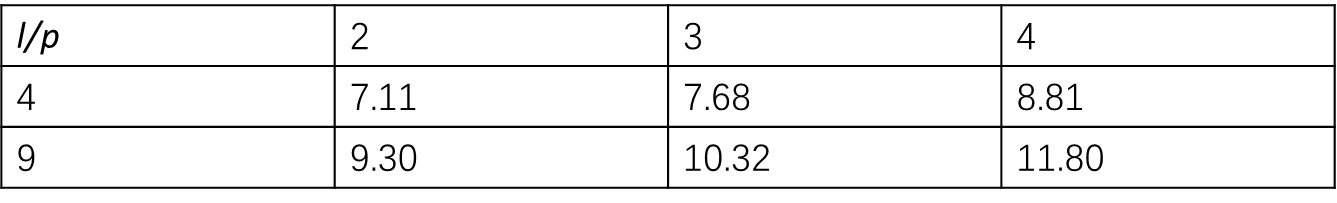
Capped Base Stock Policy: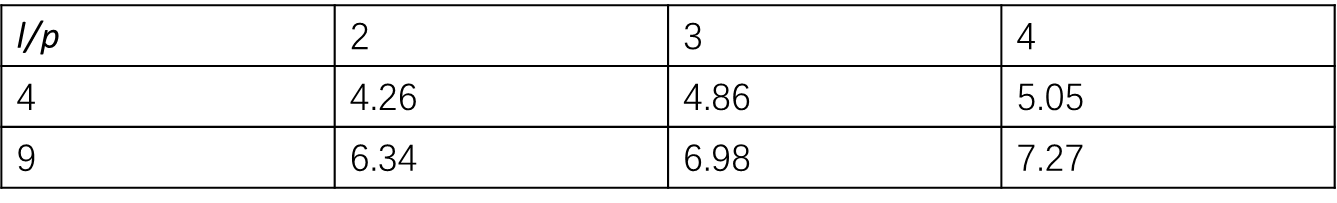
Constant Order: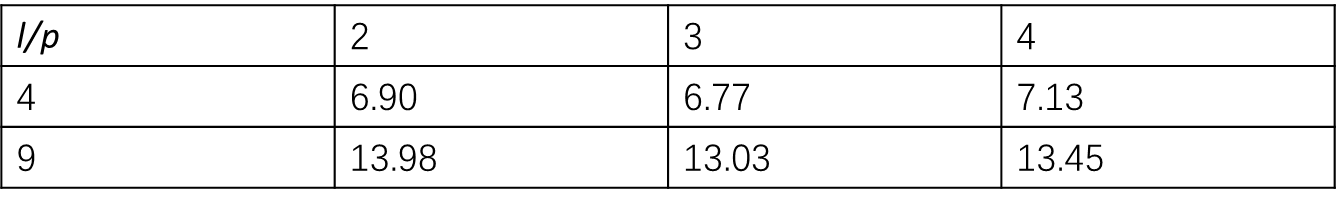
Myopic-1 Policy: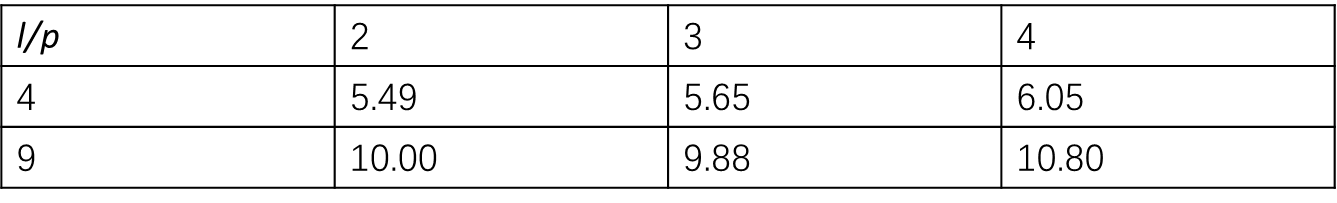


In [6]:
from project1_part_c import heuristic_guided_action

# Example of heuristic-guided improvement idea:
# use the best heuristic action as a prior action suggestion.
best_heuristic_action = heuristic_guided_action(env.reset(), env, benchmark_results)
best_heuristic_action


5

**Additional**: Can you improve your DRL algorithms(to make it converge faster or perform better) based on the provided heuristic algorithms? You may refer to https://proceedings.neurips.cc/paper_files/paper/2021/file/70d31b87bd021441e5e6bf23eb84a306-Paper.pdf and codes are available on https://github.com/microsoft/HuRL.

In [ ]:
### BEGIN HERE
### END HERE